# ToDo
- Consider more features through data sourcing
- Interpreatation of user types

In [1]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

# Load prepared dataframes from pickle files
data_path = "../data_processed/"

with open(data_path + "df_prepared.pkl", "rb") as f:
    df = pickle.load(f)

with open(data_path + "merged_df_prepared.pkl", "rb") as f:
    merged_df = pickle.load(f)

print("DataFrames loaded successfully:")
print(f"  df shape: {df.shape}")
print(f"  merged_df shape: {merged_df.shape}")

DataFrames loaded successfully:
  df shape: (65006, 21)
  merged_df shape: (65006, 27)


# Cluster Analysis

To conduct a clustering of the registered users, we first need to extract all session with a registered user and store these instances in a new variable

In [2]:
registered_users_df = merged_df[merged_df['isRegisteredUser'] == True].copy()

In [3]:
print(f"Total sessions in merged_df: {len(merged_df)}")
print(f"Sessions from registered users: {len(registered_users_df)}")
print(f"Unique registered users to cluster: {registered_users_df['userID'].nunique()}")

Total sessions in merged_df: 65006
Sessions from registered users: 47815
Unique registered users to cluster: 1006


## Preprocessing
### Feature Selection for Clustering
We only considered numerical dimensions due to the nature of the KMeans Clustering. All categoric or time data can't be processed from here. Numerical data, which is dependend on other data is extracted through the delta to reduce redundance in the data itself.

In [4]:
cluster_df_pre = registered_users_df[["kWhDelivered","charging_duration","minutesAvailable","userID"]].copy()
cluster_df_pre["session_delta"] = registered_users_df["session_duration"] - registered_users_df["charging_duration"]
cluster_df_pre["kWhRequested_delta"] = registered_users_df["kWhRequested"] - registered_users_df["kWhDelivered"]
cluster_df = cluster_df_pre.groupby("userID").mean()
cluster_df["sessions_count"] = cluster_df_pre.groupby("userID").size()

### 3-Sigma-Interval
As the cluster should represent only natural user behaviour data further out than 3 sigma is not considered. This data is rather due to extreme usage scenarios or failures in the data collection.

In [5]:
z_scores = (cluster_df - cluster_df.mean()) / cluster_df.std()
abs_z_scores = z_scores.abs()
cluster_df_cleaned = cluster_df[(abs_z_scores < 3).all(axis=1)].copy()

### Data Scalling

In [6]:
std_scaler = StandardScaler()
std_scaler.set_output(transform="pandas")
cluster_scaled_df = std_scaler.fit_transform(cluster_df_cleaned)

## Estimation of number of clusters
The elbow method as well as silhoutte method is considered. The goal is to find a good trade of from both estimates

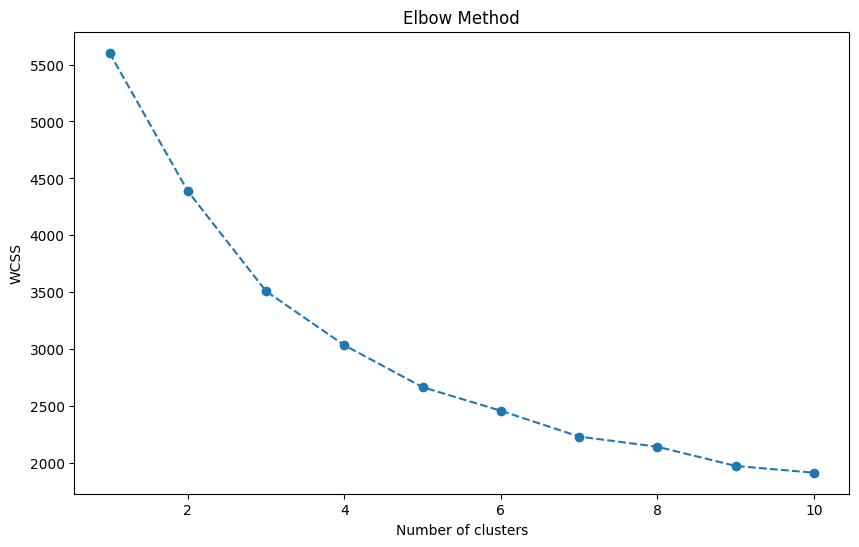

In [7]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=43)
    kmeans.fit(cluster_scaled_df)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

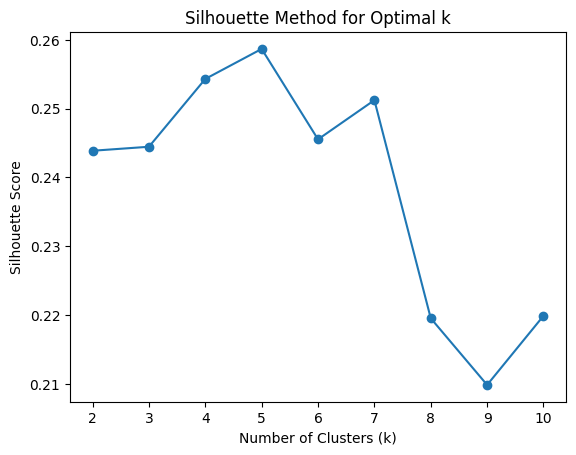

In [8]:
scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=43).fit(cluster_scaled_df)
    score = silhouette_score(cluster_scaled_df, kmeans.labels_)
    scores.append(score)

plt.plot(k_range, scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method for Optimal k')
plt.show()

## Application
The application of the KMeans alogrithm reveals different archityps of users, which differ from each other, but not in all dimensions.

### Interpretation
Cluster 1:  High Volume charger. These group is buying a relatively high amount of kwH with only a mid duration of the charging (fast chargers). Moreover they estimate they charging time and kwH need higher than they actually taking then. The small session delta shows that they end their charging before their car is filled up or shortly after. Due to their intially greater requested kwH they probably end their session before full.

Cluster 2: Oportunity chargers. This group only takes a small amount of kwH in a short time and also requests only a small amount of kwH and estimates their charging time short. Due to their short charging time and session delta they only top up their range, while they are doing something near to the hub. Moreover they are not frequent user with a smaller session count.

Cluster 3: Loyal customers: These users have a high count of sessions and are loyal to charge at our hub. They are more likely to request a longer charging time than they are actually using. The charging duration, minutes_available, kwH usage is in average and rather low compared to chargers with big volume.

Cluster 4: Parking lot with charger users. These people have only take a small percentage of kwH within a mid charging time. They also estimater their charging time average and they request kwH precissed. They have a high session delta, which means that they leave their car after the charging time in the hub, which indicates that they parking there.

Cluster 5: Power consumers. This group is requesting and then charging a big amount of kwH. According to that they request a long charging period and then also using that. Their standing time after charging is small and moreover they do not use the hub very often, only a few sessions each.

In [ ]:
def renameClusters(record):
    match record:
        case 0:
            return "High Volume chargers"
        case 1:
            return "Oportunity chargers"
        case 2:
            return "Power consumers"
        case 3:
            return "Parking users"
        case 4:
            return "Loyal customers"


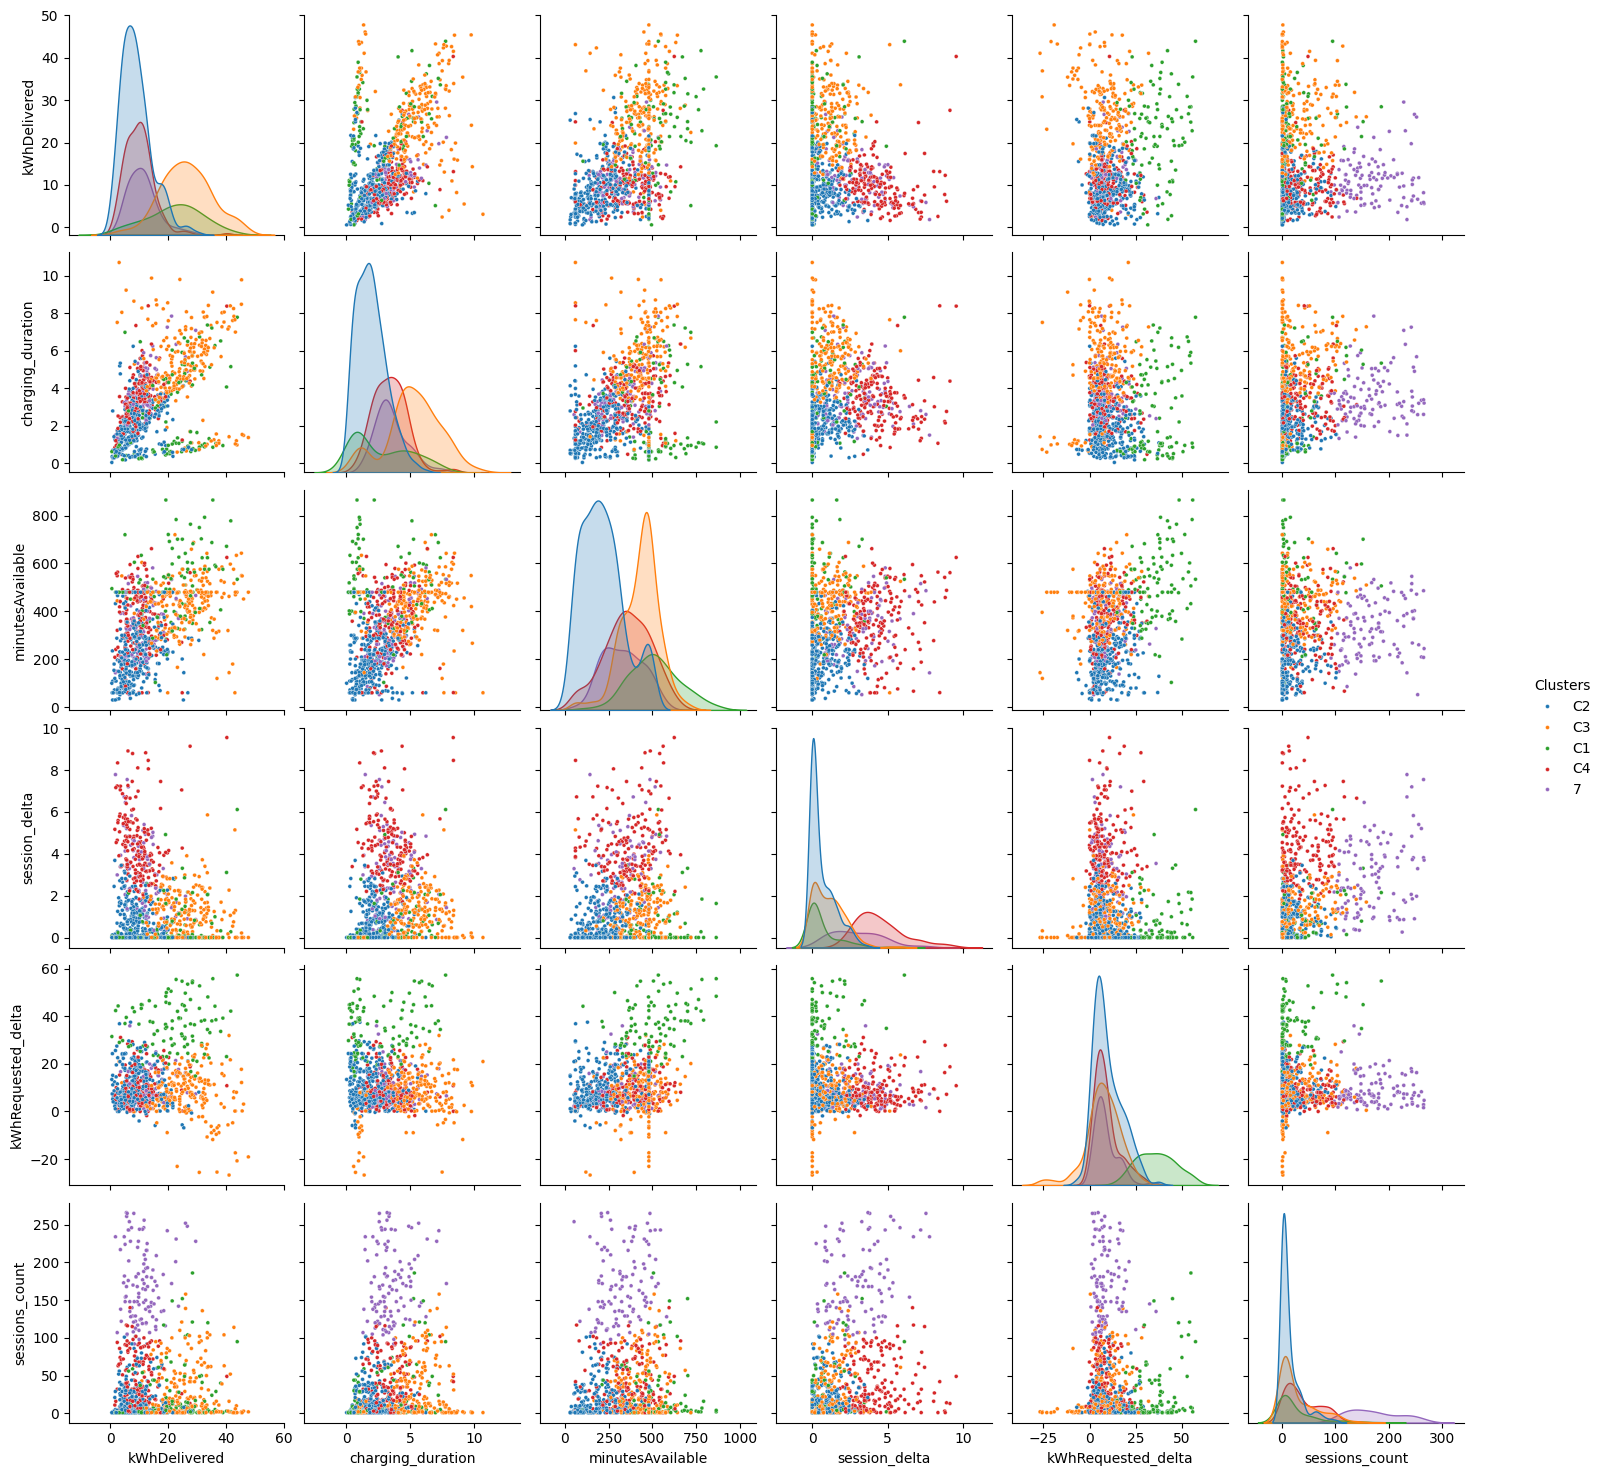

In [38]:
kmeans = KMeans(n_clusters=5, random_state=43)
kmeans_labels = kmeans.fit_predict(cluster_scaled_df)
cluster_df_cleaned["kmeans_labels"] = kmeans_labels
cluster_df_cleaned["kmeans_labels"]= cluster_df_cleaned["kmeans_labels"].apply(lambda x: renameClusters(x))

g = sns.pairplot(cluster_df_cleaned, hue="kmeans_labels", plot_kws={"s": 8}, palette='tab10')
g.legend.set_title("Clusters")
plt.savefig("../graphs/clustering.png")